## Ridge model using the new feature-engineered dataset

In [2]:
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("../data/processed/features_dataset.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,price,actual_load,actual_residual_load,forecasted_load,forecasted_residual_load,actual_biomass,actual_hydropower,actual_wind_offshore,actual_wind_onshore,...,actual_wind_total_lag_168,actual_solar_lag_24,actual_solar_lag_48,actual_solar_lag_168,actual_renewable_total_lag_24,actual_renewable_total_lag_48,actual_renewable_total_lag_168,actual_fossil_total_lag_24,actual_fossil_total_lag_48,actual_fossil_total_lag_168
0,2023-01-08 00:00:00,10.93,42509.00,9800.50,45539.50,15149.50,4310.50,1253.75,6970.75,25735.75,...,32006.50,2.00,2.0,1.75,24846.00,22315.50,37297.75,12187.50,16580.50,7520.50
1,2023-01-08 01:00:00,9.07,40708.50,8869.25,44589.75,15959.50,4278.25,1317.00,7072.25,24765.00,...,33173.50,2.00,2.0,2.00,24357.75,23942.25,38395.25,11837.25,16450.25,7355.50
2,2023-01-08 02:00:00,9.10,39829.75,9224.25,43714.50,16142.75,4269.75,1315.25,7017.50,23586.00,...,33357.00,2.00,2.0,1.75,24996.50,26234.00,38548.50,11249.50,16265.50,7329.50
3,2023-01-08 03:00:00,4.16,40059.50,11072.00,42552.75,16497.75,4262.50,1245.25,6748.25,22237.25,...,30956.75,2.00,2.0,2.00,25907.25,28296.25,36155.00,10655.75,15222.50,7334.25
4,2023-01-08 04:00:00,5.58,40147.00,11819.50,42979.75,17909.00,4277.25,1239.50,6861.25,21464.00,...,30401.25,2.25,2.0,2.25,26356.75,30444.50,35644.00,10588.00,14706.00,7312.00


In [4]:
train = df[df["timestamp"] < "2026-01-01"].copy()
test = df[df["timestamp"] >= "2026-01-01"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (26133, 50)
Test shape: (960, 50)


In [5]:
target = "price"

drop_cols = ["timestamp", target]

feature_cols = [col for col in df.columns if col not in drop_cols]

X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

print("Number of features:", len(feature_cols))

Number of features: 48


In [6]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [7]:
ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)

print(f"Ridge MAE: {ridge_mae:.3f}")

Ridge MAE: 13.948


In [8]:
ridge_results = test[["timestamp", "price"]].copy()
ridge_results["ridge_prediction"] = ridge_pred
ridge_results["absolute_error"] = abs(ridge_results["price"] - ridge_results["ridge_prediction"])

ridge_results.to_csv("../outputs/predictions/ridge_predictions.csv", index=False)

ridge_results.head()

,timestamp,price,ridge_prediction,absolute_error
26133,2026-01-01 00:00:00,58.28,44.450878,13.829122
26134,2026-01-01 01:00:00,42.40,40.815444,1.584556
26135,2026-01-01 02:00:00,19.57,32.522826,12.952826
26136,2026-01-01 03:00:00,6.29,25.635231,19.345231
26137,2026-01-01 04:00:00,3.09,19.945790,16.855790


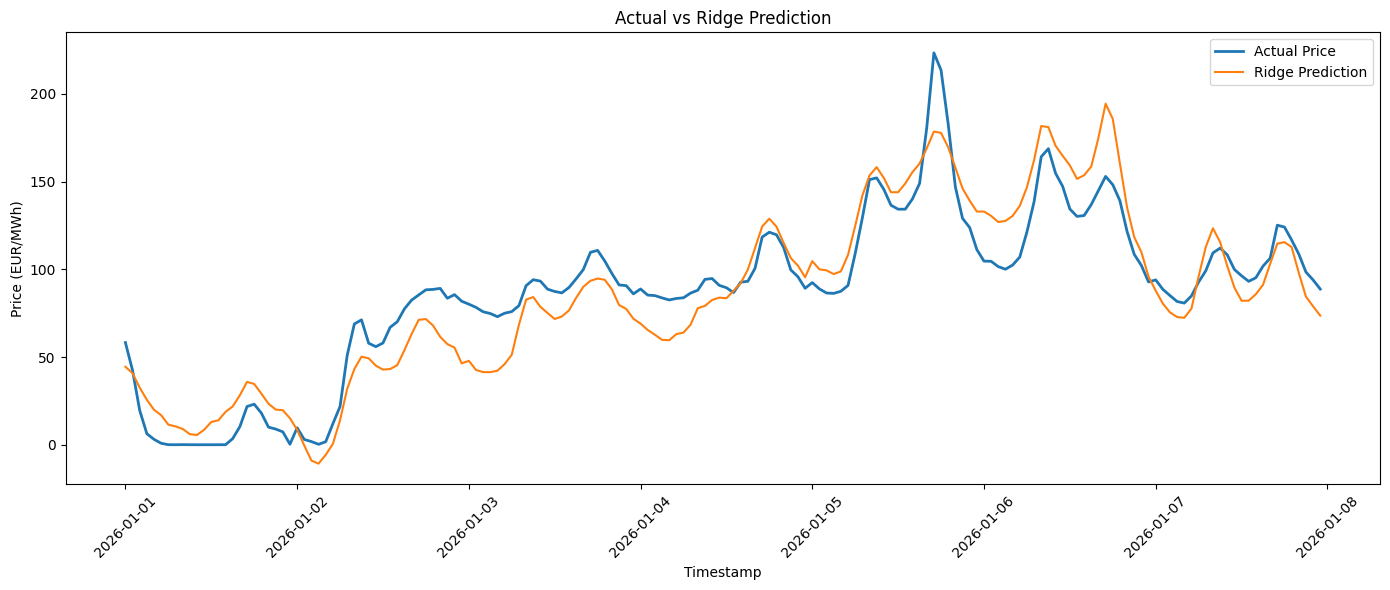

In [9]:
import matplotlib.pyplot as plt

plot_data = ridge_results[
    (ridge_results["timestamp"] >= "2026-01-01") &
    (ridge_results["timestamp"] < "2026-01-08")
].copy()

plt.figure(figsize=(14, 6))

plt.plot(plot_data["timestamp"], plot_data["price"], label="Actual Price", linewidth=2)
plt.plot(plot_data["timestamp"], plot_data["ridge_prediction"], label="Ridge Prediction")

plt.title("Actual vs Ridge Prediction")
plt.xlabel("Timestamp")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/figures/actual_vs_ridge_prediction.png", dpi=300)
plt.show()